# Common projection centers: computational laboratory

This notebook accompanies **Common projection centers: Gale configurations, boundary geometry, and section algebras** (revised manuscript, 2026).

Run it from the extracted project folder. It uses `geometry.py`, `algebra.py`, `slice_exact.py`, and `gale_signature.py`. Install NumPy and Matplotlib from `requirements.txt`. The interactive companion is `common_centers_lab.html`.

The geometry plots are real slices or affine shadows. Theorems in the paper concern general configurations over an algebraically closed field of characteristic zero. Floating-point residuals below test an implementation; they do not prove the general theorems.


In [1]:
import json
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from geometry import configuration, centers, exceptional, matching, distance, verify
from algebra import invariants, sections, coordinates, betti
from slice_exact import slice_instance
from gale_signature import signature, transform
print('NumPy', np.__version__)
print('Modules loaded. Geometry examples: d = 3, 4, 5.')


NumPy 2.3.5
Modules loaded. Geometry examples: d = 3, 4, 5.


## 1. Generate a valid pair and recover the projectivity

For $N=d+3$, let $K_X=\ker X$ and $K_Y=\ker Y$. At an ordinary parameter pair, $D=\operatorname{diag}(k_i/\ell_i)$ yields $L_X(a)=DL_Y(b)$. Quotient cameras then satisfy $P_bY=H(P_aX)D$.

Change `d`, `theta`, or `psi` and rerun. The code constructs quotient cameras independently of the cleared coordinate formulas and computes the matrix $H$.


In [2]:
d = 4
data = configuration(d)
theta, psi = 0.33, -0.64
result = matching(data, theta, psi)
print('N =', d+3)
print('center a:', np.array(result['a']))
print('center b:', np.array(result['b']))
print('relative matching residual:', result['residual'])
print('largest projective image discrepancy:', result['image_distance'])
print('H =\n', np.array(result['H']))


N = 7
center a: [-0.40109477 -0.4587477   0.22209842 -0.7581066   0.06797213]
center b: [ 0.79428139  0.0404963  -0.30025014  0.31279604 -0.42365743]
relative matching residual: 7.56341424885056e-16
largest projective image discrepancy: 1.1116099371267112e-15
H =
 [[-0.24932074 -0.01999619 -0.11897939 -0.59079387]
 [ 0.51793805  0.58282182  0.87895319  0.19863944]
 [-0.06338947 -0.02746465 -1.0645256  -0.26436095]
 [-0.27472532  0.37003066 -0.38900601  0.03439973]]


## 2. Resolve a base point instead of dividing by zero

At $(t_i,s_i)$, the raw coordinate vectors vanish. A direction $[\xi:\eta]=[\cos\phi:\sin\phi]$ determines a point on $E_i$. The function `exceptional` evaluates the first-derivative formula at that direction. The two excluded directions are $\phi=0$ and $\phi=\pi/2$.


Matching residual on E_i: 9.49384379519128e-16


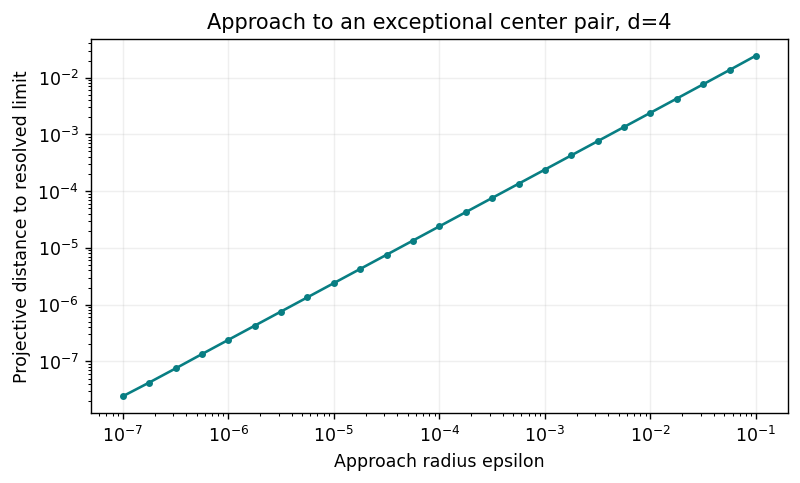

In [3]:
i, phi = 0, 0.61
limit = exceptional(data, i, phi)
exception_result = matching(data, exception=(i,phi))
print('Matching residual on E_i:', exception_result['residual'])
epsilons = np.logspace(-1,-7,25)
errors=[]
for epsilon in epsilons:
    nearby=centers(data, np.arctan(data['t'][i]+epsilon*np.cos(phi)),
                   np.arctan(data['s'][i]+epsilon*np.sin(phi)))
    errors.append(max(distance(x,y) for x,y in zip(nearby,limit)))
fig,ax=plt.subplots(figsize=(6.5,4))
ax.loglog(epsilons,errors,'o-',color='#087e83',ms=3)
ax.set(xlabel='Approach radius epsilon',ylabel='Projective distance to resolved limit',
       title='Approach to an exceptional center pair, d=4')
ax.grid(alpha=.2)
fig.tight_layout()
plt.show()


## 3. Compare the two rings

The full section dimension is

$$h^0(pA+qB)=1+\frac{(d-1)(p^2+q^2)+2(d^2+d-1)pq+(d+1)(p+q)}2.$$

The coordinate ring differs only at $(1,1)$, by $d-1$ sections. This produces the finite normalization sequence. The table below evaluates the **proved normalization Betti formula**, not a computed resolution of the original ring $R$.


In [4]:
print(json.dumps(invariants(d),indent=2))
print('At (1,1): full =',sections(d,1,1),'coordinate =',coordinates(d,1,1))
for homological in range(2*d-1):
    terms=[f'T(-{r["p"]},-{r["q"]})^{r["value"]}' for r in betti(d) if r['i']==homological]
    print(homological, ':', ' + '.join(terms))


{
  "d": 4,
  "N": 7,
  "scroll": [
    1,
    2
  ],
  "multidegree": [
    3,
    19,
    3
  ],
  "segre_degree": 44,
  "sectional_genus": 18,
  "boundary_components": 14,
  "boundary_nodes": 42,
  "log_canonical_square": 43,
  "complex_euler": 25,
  "missing_sections": 3,
  "normalization_regularity": 2,
  "coordinate_regularity": 3
}
At (1,1): full = 28 coordinate = 25
0 : T(-0,-0)^1 + T(-1,-1)^3
1 : T(-0,-2)^3 + T(-1,-2)^21 + T(-2,-0)^3 + T(-2,-1)^21
2 : T(-0,-3)^2 + T(-1,-3)^33 + T(-2,-2)^99 + T(-3,-0)^2 + T(-3,-1)^33
3 : T(-1,-4)^15 + T(-2,-3)^123 + T(-3,-2)^123 + T(-4,-1)^15
4 : T(-2,-4)^48 + T(-3,-3)^139 + T(-4,-2)^48
5 : T(-3,-4)^51 + T(-4,-3)^51
6 : T(-4,-4)^18


## 4. Make the degree count visible, with an exact certificate

One general hyperplane constraint on each center intersects the surface in $AB=d^2+d-1$ complex points, counted with multiplicity. Here the specified rational example has a squarefree residual eliminant, so its points are distinct. Before counting, remove the $d+3$ base-point factors.

The univariate degree, gcds, and Sturm real-root count are exact. Only the root locations in the plot are approximate. The hyperplanes here are expressed in the integer configuration coordinates printed in the certificate; those are projectively equivalent to the viewer's orthonormal coordinates.


raw_eliminant_degree : 26
base_factors_removed : 7
residual_degree : 19
squarefree : True
denominator_coprime : True
base_coprime : True
exact_real_roots : 9
complex_nonreal_roots : 10
max_relative_polynomial_residual : 7.107775284226286e-17


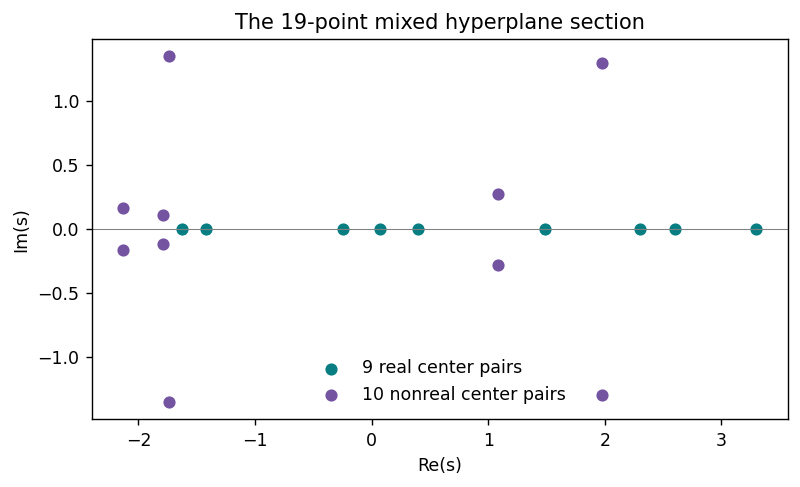

In [5]:
certificate=slice_instance(4)
for key in ['raw_eliminant_degree','base_factors_removed','residual_degree',
            'squarefree','denominator_coprime','base_coprime','exact_real_roots',
            'complex_nonreal_roots','max_relative_polynomial_residual']:
    print(key,':',certificate[key])
z=np.array([p['s'] for p in certificate['approximate_points']])
real=abs(z[:,1])<1e-7
fig,ax=plt.subplots(figsize=(6.5,4))
ax.scatter(*z[real].T,color='#087e83',label='9 real center pairs')
ax.scatter(*z[~real].T,color='#7453a1',label='10 nonreal center pairs')
ax.axhline(0,lw=.6,color='gray')
ax.set(xlabel='Re(s)',ylabel='Im(s)',title='The 19-point mixed hyperplane section')
ax.legend(frameon=False)
fig.tight_layout()
plt.show()


## 5. Compress a marked configuration to projective invariants

Normalize the first three Gale points to $\infty,0,1$. The remaining points give $N-3=d$ cross-ratios on each factor: $2d$ coordinates in total. This is a marked projective signature on the chosen chart, not a metric similarity score or an unordered point matcher.


In [6]:
from fractions import Fraction
t=[-3,-2,-1,0,1,2,3]
s=[Fraction(x,10) for x in [-24,17,-3,28,-11,6,-32]]
sig=(signature(t),signature(s))
changed=(signature(transform(t,2,3,1,7)),signature(transform(s,-1,4,2,9)))
assert sig==changed
print('Two projectivities leave the eight invariants unchanged:')
print([[str(v) for v in row] for row in sig])


Two projectivities leave the eight invariants unchanged:
[['4/3', '3/2', '8/5', '5/3'], ['-231/1040', '147/65', '77/200', '-1029/160']]


## Sources and next experiments

- [Ottaviani and Thomas, the common-image problem](https://arxiv.org/abs/2603.14172).
- [Eisenbud and Popescu, The Projective Geometry of the Gale Transform](https://arxiv.org/abs/math/9807127).
- [Hartley and Zisserman, Multiple View Geometry](https://www.robots.ox.ac.uk/~vgg/hzbook/).
- [Macaulay2 multigraded Betti tables](https://macaulay2.com/doc/Macaulay2/share/doc/Macaulay2/Macaulay2Doc/html/___Multigraded__Betti__Tally.html).
- [HomotopyContinuation.jl parameter homotopies](https://www.juliahomotopycontinuation.org/guides/parameter-homotopies/).

Concrete extensions: vary the hyperplanes and track the 19 points; determine their discriminant and real-root chambers; compute the original ring's remaining mixed syzygies; compare projective signatures across differently represented copies of the same marked input.
